# FARGOpy
## Wrapping FRAGO3D

### What's in this notebook


This notebook demonstrates how to use the `FARGOpy` library to perform advanced calculations and analyses on simulation data from `FARGO3D`. The main focus is on calculating integrals over a general surface or volume and visualizing the results.

Key sections include:

- **Creating a Sphere Object**: Define a spherical surface for 3D analysis, specifying its radius, center, and subdivisions.

- **Analyzing Data**:
  - Create an `Analyzer` object to perform calculations on the simulation data.
  - Define custom integrand functions for specific analyses, such as calculating flux over a surface.

- **Performing Integrals**:
  - Calculate integrals over a surface or volume using the `Analyzer` object.
  - Use a user-defined integrand function to compute the desired quantity, such as flux or other physical properties.

- **Visualizing Results**:
  - Plot the calculated results as a function of time.
  - Highlight key metrics, such as the average value of the computed integral, for better interpretation.

This notebook serves as a practical guide for users to explore and analyze `FARGO3D` simulation data using `FARGOpy`, focusing on integral-based calculations and their visualization.

### Before starting

If you are in `Google Colab`, install the latest version of the package:

In [1]:
# @title Install fargopy
import sys
if 'google.colab' in sys.modules:
    !sudo pip install -Uq fargopy

For this tutorial you will need the following external modules and tools:

In [2]:
import fargopy as fp
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

%load_ext autoreload
%autoreload 2

Running FARGOpy version 0.4.0


### Let's `FARGOpy`

First we need the data. Let's download a precomputed simulation. Check the list:

In [3]:
fp.Simulation.list_precomputed()

fargo:
	Description: Protoplanetary disk with a Jovian planet [2D]
	Size: 55 MB
p3diso:
	Description: Protoplanetary disk with a Super earth planet [3D]
	Size: 220 MB
p3disoj:
	Description: Protoplanetary disk with a Jovian planet [3D]
	Size: 84 MB
fargo_multifluid:
	Description: Protoplanetary disk with several fluids (dust) and a Jovian planet in 2D
	Size: 100 MB
binary:
	Description: Disk around a binary with the properties of Kepler-38 in 2D
	Size: 140 MB


Download, for instance, the 3D simulation of a disk with a Jovian planet:

In [3]:
fp.Simulation.download_precomputed('p3disoj')

Downloading...
From: https://docs.google.com/uc?export=download&id=1Xzgk9qatZPNX8mLmB58R9NIi_YQUrHz9
To: /tmp/p3disoj.tgz
100%|██████████| 84.2M/84.2M [00:03<00:00, 22.8MB/s]


Uncompressing p3disoj.tgz into /tmp/p3disoj
Done.


Once download it, we need to connect a `Simulation` with the directory with the simulation results:

In [4]:
#sim = fp.Simulation(output_dir='/home/jupitergeci/fargowork/data/fargo_data')
sim = fp.Simulation(output_dir='/tmp/p3disoj')

Your simulation is now connected with '/home/jupitergeci/fargo3d/'
Now you are connected with output directory '/tmp/p3disoj'
Found a variables.par file in '/tmp/p3disoj', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 128 [[0, np.float64(-3.117048960983623)], [-1, np.float64(3.117048960983623)]]
	Variable r: 64 [[0, np.float64(0.5078125)], [-1, np.float64(1.4921875)]]
	Variable theta: 32 [[0, np.float64(1.4231400767948967)], [-1, np.float64(1.5684525767948965)]]
Number of snapshots in output directory: 11
Planets found in summary.dat:
  Name: Jupiter, Distance: 1.0, Mass: 0.001
Configuration variables and domains load into the object. See e.g. <sim>.vars


In [6]:
sim.load_planet_summary()

[{'name': 'Jupiter', 'distance': 1.0, 'mass': 0.001}]

Now we load the data from `FARGO3D`simulation results for a visualization:

In [7]:
gasd = sim.load_field('gasdens',snapshot=10,type='scalar')


gasd_xz_slice,mesh0 = gasd.meshslice(slice='phi=0')
gasd_xy_slice,mesh1 = gasd.meshslice(slice='theta=1.56')

### Create the surface object

In [8]:

sphere = fp.Surface.Sphere(radius=0.069, subdivisions=1, center=(1.0, 0.0, 0.0))

In [9]:
type(sphere)

fargopy.flux.Surface.Sphere

Visualize the sphere object

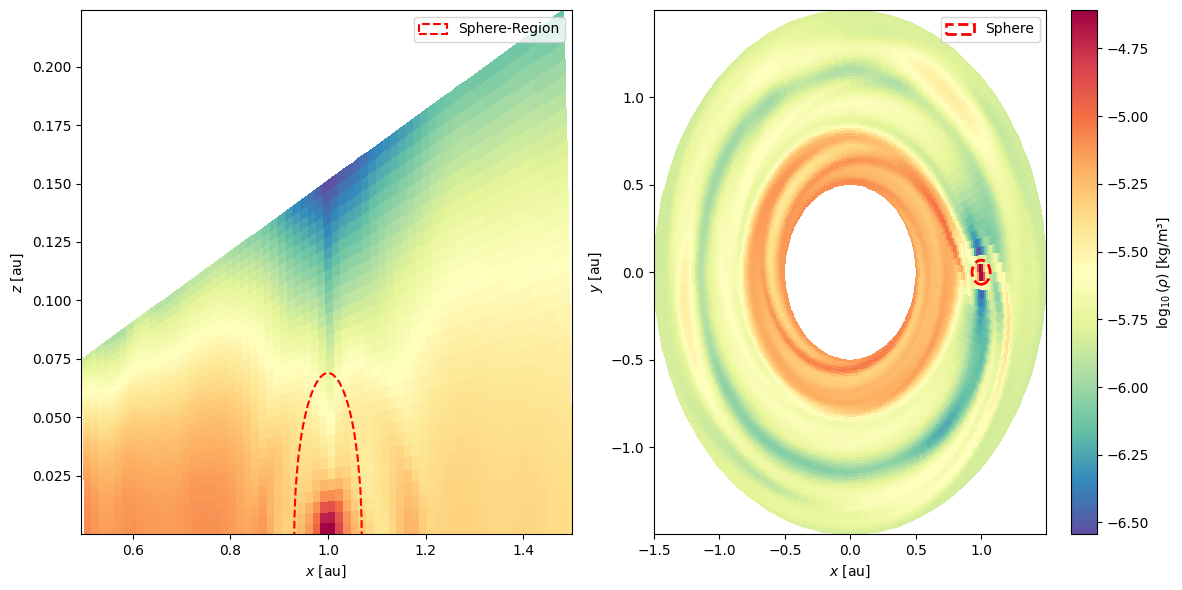

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

cmap = 'Spectral_r'

# Colormap of the logarithmic density for the XZ plane
ax = axs[0]
pc = ax.pcolormesh(
    mesh0.x * sim.UL / fp.AU,
    mesh0.z * sim.UL / fp.AU,
    np.log10(gasd_xz_slice * sim.URHO * 1e3),
    cmap=cmap
)
ax.set_xlabel('$x$ [au]')
ax.set_ylabel('$z$ [au]')

# Add a circle to the XZ plane
circle_xz = plt.Circle(
    (sphere.center[0], sphere.center[2]),  # Center in the XZ plane
    sphere.radius * sim.UL / fp.AU,        # Radius in AU
    color='red',
    fill=False,
    linestyle='--',
    linewidth=1.5,
    label='Sphere-Region'
)
ax.add_artist(circle_xz)
ax.legend()

# Colormap of the logarithmic density for the XY plane
ax = axs[1]
pc = ax.pcolormesh(
    mesh1.x * sim.UL / fp.AU,
    mesh1.y * sim.UL / fp.AU,
    np.log10(gasd_xy_slice * sim.URHO * 1e3),
    cmap=cmap
)
ax.set_xlabel('$x$ [au]')
ax.set_ylabel('$y$ [au]')

# Add a circle to the XY plane
circle_xy = plt.Circle(
    (sphere.center[0], sphere.center[1]),  # Center in the XY plane
    sphere.radius * sim.UL / fp.AU,        # Radius in AU
    color='red',
    fill=False,
    linestyle='--',
    linewidth=2,
    label='Sphere'
)
ax.add_artist(circle_xy)
ax.legend()

# Add colorbar
fig.colorbar(pc, ax=axs[1], label=r"$\log_{10}(\rho)$ [kg/m³]")

plt.tight_layout()
plt.show()

Create the `Sphere` object filtered for $z>0$


In [11]:
sphere = fp.Surface.Sphere(
    radius=0.069, 
    subdivisions=6, 
    center=(1.0, 0.0, 0.0)
)


sphere.filter("z>0.003")


The sphere object have different atributes the most important are: `sphere.centers`, `sphere.areas` and `sphere.volumes` each one is an array of n-subdivision elements in wich are stored the centers,areas and volumes of the sphere tesselation. 

In [12]:
sphere.centers

array([[0.96227815, 0.05768535, 0.00315071],
       [0.96341291, 0.05838667, 0.00358415],
       [0.96456266, 0.0590638 , 0.00401593],
       ...,
       [1.06341034, 0.02685637, 0.00426478],
       [1.06422073, 0.02496712, 0.00355892],
       [1.0639182 , 0.02573191, 0.00355771]], shape=(39176, 3))

Now we can interpolate the fields over the surface, specifically on the centers of tesselation triangles:

In [13]:
# Coordinates of the sphere centers
xcs=sphere.centers[:, 0]
ycs=sphere.centers[:, 1]
zcs=sphere.centers[:, 2]

In [14]:
# Load the 3D gas density field from the simulation
dens3d = sim.load_field(
    fields='gasdens',
    snapshot=10,
    interpolate=True)

zmin=dens3d.df.var3_mesh[0].min()

Loading 3D density data 


In [15]:
density = dens3d.evaluate(
   time=10,
   var1=xcs,
   var2=ycs,
   var3=zcs,
   interpolator='idw',
  idw_kwargs={"power": 2, "k": 30})
        
# density = dens3d.evaluate(
#     time=10,
#     var1=xcs,
#     var2=ycs,
#     var3=zcs,
#     interpolator='griddata',
#     method='nearest'
#     )
        

Running FARGOpy version 0.4.0


Lets see the 3D Density field over the surface:

In [16]:
import plotly.graph_objects as go

fig = go.Figure(data=go.Scatter3d(
    x=xcs.flatten(),
    y=ycs.flatten(),
    z=zcs.flatten(),
    mode='markers',
    marker=dict(
        size=2,
        color=np.log(density.flatten()),  # Color según la densidad interpolada
        colorscale='Spectral_r',
        opacity=1,
        colorbar=dict(title='Density log[g cm^-2]'),
    )
))

fig.update_layout(
    scene=dict(
        xaxis_title='X [au]',
        yaxis_title='Y [au]',
        zaxis_title='Z [au]',
        aspectmode='data'
    ),
    title='IDW Interpolation on Sphere Centers in 3D Gas Density Field',
)

fig.show()

## 2D Projection

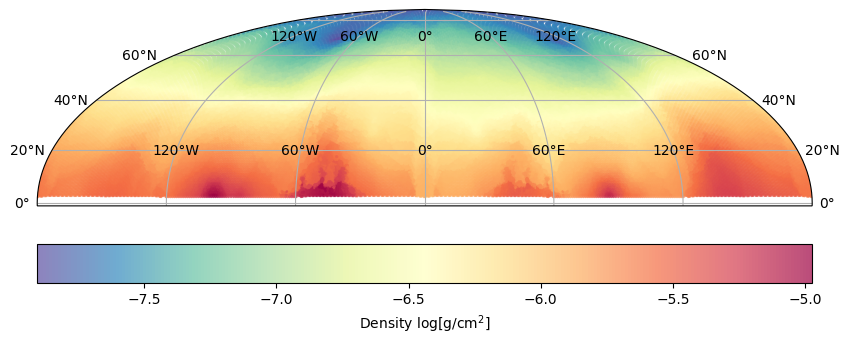

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs


x0, y0, z0 = 1, 0, 0
xcs_shifted = xcs - x0
ycs_shifted = ycs - y0
zcs_shifted = zcs - z0

# Convierte a coordenadas esféricas
r = np.sqrt(xcs_shifted**2 + ycs_shifted**2 + zcs_shifted**2)
lat = np.degrees(np.arcsin(zcs_shifted / r))
lon = np.degrees(np.arctan2(ycs_shifted, xcs_shifted))


fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.Mollweide())
sc = ax.scatter(
    lon, lat, c=np.log(density), s=2, cmap='Spectral_r',
    transform=ccrs.PlateCarree(), alpha=0.7
)
# ax.coastlines()  # <- No mostrar contorno
ax.gridlines(draw_labels=True)

plt.colorbar(sc, orientation='horizontal', pad=0.05, label='Density log[g/cm$^2$]')
plt.show()

## 2D Projection With Plotly

In [ ]:
import plotly.graph_objects as go
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs


x0, y0, z0 = 1, 0, 0
xcs_shifted = xcs - x0
ycs_shifted = ycs - y0
zcs_shifted = zcs - z0


r = np.sqrt(xcs_shifted**2 + ycs_shifted**2 + zcs_shifted**2)
lat = np.degrees(np.arcsin(zcs_shifted / r))
lon = np.degrees(np.arctan2(ycs_shifted, xcs_shifted))


fig = go.Figure(go.Scattergeo(
    lon=lon,  
    lat=lat,  
    mode='markers',
    marker=dict(
        size=2,
        color=np.log(density),
        colorscale='Spectral_r',
        opacity=1,
        colorbar=dict(title='Density log[g cm^-2]')
    )
))

fig.update_geos(
    projection_type="mollweide",
    lataxis=dict(griddash="solid",range=[0,90],showgrid=True, gridcolor="black", gridwidth=1),
    lonaxis=dict(griddash="solid",range=[-180,180],showgrid=True, gridcolor="black", gridwidth=1),
    showcountries=False,
    showcoastlines=False,
    showland=False,
    showocean=False,
    showframe=False,
)
fig.update_layout(
    margin={"r":5,"t":20,"l":5,"b":20}
)
fig.show()

# Analyzer

In [93]:
analyzer= fp.Analyzer(
    simulation=sim,
    surface=sphere,
    fields=['gasdens','gasv'],
    snapshots=(0,10),
    interpolator='idw',
    interp_kwargs={"power": 3, "k": 20}
)

Loading 3D density data 
Loading 3D gas velocity data


# Matter Flux

Define the integrand function, in this case flux over 3D surface:

In [95]:

integrand = lambda gasdens, gasv: gasdens * np.sum(gasv * sphere.normals, axis=1)

Calculate the flux integral:

In [98]:
flux = analyzer.calculate_integral(integrand=integrand, time_steps=50,dtype='area')

Calculating integral:   0%|          | 0/50 [00:00<?, ?it/s]

Calculating integral: 100%|██████████| 50/50 [13:56<00:00, 16.74s/it]


plot the results:

Text(1, 1, 'FARGOpy 0.3.15')

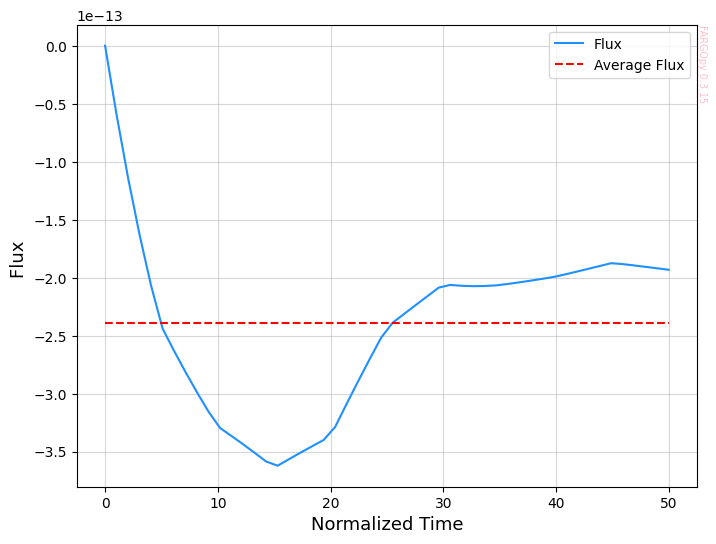

In [102]:
flux_msun = flux*sim.UM/sim.UT *1e-3*1/(1.989e30)


flux_averaged = np.mean(flux_msun)


fig,axs = plt.subplots(1,1,figsize=(8,6))



# Colormap of the logaritmic density
axs.plot(np.linspace(0, 50, 50), flux_msun, label='Flux', color='dodgerblue')
axs.hlines(y=flux_averaged, xmin=0, xmax=50, color='red', linestyle='--', label='Average Flux')
axs.set_xlabel('Normalized Time',size=13)
axs.set_ylabel('Flux ',size=13)
axs.legend()
axs.grid(alpha=0.5)
fp.Plot.fargopy_mark(axs)



## Matter flux heatmap

In [1]:
import fargopy as fp
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

%load_ext autoreload
%autoreload 2

Running FARGOpy version 0.4.0


In [2]:
fp.Simulation.download_precomputed('p3disoj')

Downloading...
From: https://docs.google.com/uc?export=download&id=1Xzgk9qatZPNX8mLmB58R9NIi_YQUrHz9
To: /tmp/p3disoj.tgz
100%|██████████| 84.2M/84.2M [00:03<00:00, 24.5MB/s]


Uncompressing p3disoj.tgz into /tmp/p3disoj
Done.


In [3]:
sim = fp.Simulation(output_dir='/home/jupitergeci/fargowork/data/fargo_data')
#sim = fp.Simulation(output_dir='/tmp/p3disoj')

Your simulation is now connected with '/home/jupitergeci/fargo3d/'
Now you are connected with output directory '/home/jupitergeci/fargowork/data/fargo_data'
Found a variables.par file in '/home/jupitergeci/fargowork/data/fargo_data', loading properties
Loading variables
93 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 256 [[0, np.float64(-1.564660403643354)], [-1, np.float64(1.564660403643354)]]
	Variable r: 128 [[0, np.float64(0.50390625)], [-1, np.float64(1.49609375)]]
	Variable theta: 32 [[0, np.float64(1.44319539835739)], [-1, np.float64(1.5687709152323963)]]
Number of snapshots in output directory: 216
Planets found in summary.dat:
  Name: jupiter, Distance: 1.0, Mass: 0.001
Configuration variables and domains load into the object. See e.g. <sim>.vars


In [4]:
sphere = fp.Surface.Sphere(
    radius=0.0689, 
    subdivisions=6, 
    center=(1.0, 0.0, 0.0)
)


sphere.filter("z>0.002")

In [5]:
# Load the 3D gas density field from the simulation
dens3d,vel3d = sim.load_field(
    fields=['gasdens','gasv'],
    snapshot=200,
    interpolate=True)

zmin=dens3d.df.var3_mesh[0].min()

Loading density field
Loading velocity field


Surface Flux

In [6]:
xcs = sphere.centers[:, 0]
ycs = sphere.centers[:, 1]
zcs = sphere.centers[:, 2]

In [7]:
rho = dens3d.evaluate(
   time=200,
   var1=xcs,
   var2=ycs,
   var3=zcs,
   interpolator='idw',
  idw_kwargs={"power": 2, "k": 30})


vel = vel3d.evaluate(
   time=200,
   var1=xcs,
   var2=ycs,
   var3=zcs,
   interpolator='idw',
  idw_kwargs={"power": 2, "k": 30})

Running FARGOpy version 0.4.0
Running FARGOpy version 0.4.0
Running FARGOpy version 0.4.0
Running FARGOpy version 0.4.0


In [8]:
Ms = rho * sphere.areas * np.sum(vel.T*sphere.normals,axis=1)

M_sy = sim.UM/sim.UL**3 * sim.UL**2 * sim.UL/sim.UT * Ms *1.58667e-26




In [17]:
import plotly.graph_objects as go

fig = go.Figure(data=go.Scatter3d(
    x=xcs.flatten(),
    y=ycs.flatten(),
    z=zcs.flatten(),
    mode='markers',
    marker=dict(
        size=2,
        color=M_sy,  # Color según la densidad interpolada
        colorscale='Spectral_r',
        opacity=1,
        colorbar=dict(tickformat=".2e",title='Planet Accretion Msun/yr'),
    )
))

fig.update_layout(
    scene=dict(
        xaxis_title='X [au]',
        yaxis_title='Y [au]',
        zaxis_title='Z [au]',
        aspectmode='data'
    ),

)

fig.show()

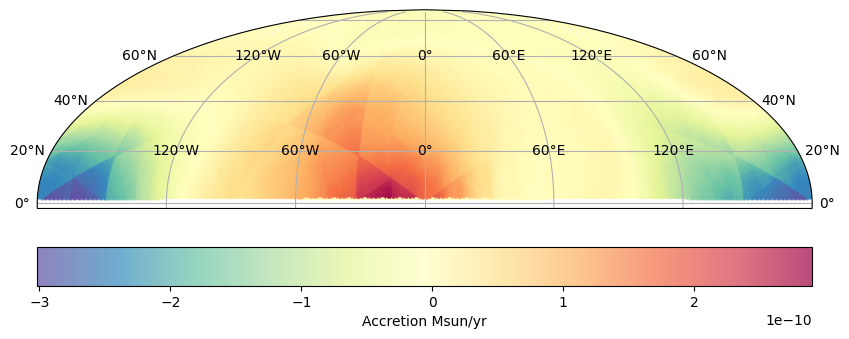

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs


x0, y0, z0 = 1, 0, 0
xcs_shifted = xcs - x0
ycs_shifted = ycs - y0
zcs_shifted = zcs - z0

# Convierte a coordenadas esféricas
r = np.sqrt(xcs_shifted**2 + ycs_shifted**2 + zcs_shifted**2)
lat = np.degrees(np.arcsin(zcs_shifted / r))
lon = np.degrees(np.arctan2(ycs_shifted, xcs_shifted))


fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.Mollweide())
sc = ax.scatter(
    lon, lat, c=M_sy, s=2, cmap='Spectral_r',
    transform=ccrs.PlateCarree(), alpha=0.7
)
# ax.coastlines()  # <- No mostrar contorno
ax.gridlines(draw_labels=True)

plt.colorbar(sc, orientation='horizontal', pad=0.05, label='Accretion Msun/yr')
plt.show()

In [ ]:
import plotly.graph_objects as go

fig = go.Figure(data=go.Scatter3d(
    x=dens3d.var1_mesh[0].flatten(),
    y=dens3d.var2_mesh[0].flatten(),
    z=dens3d.var3_mesh[0].flatten(),
    mode='markers',
    marker=dict(
        size=2,
        color=np.log(dens3d.gasdens_mesh[0].flatten()),  # Color según la densidad interpolada
        colorscale='Spectral_r',
        opacity=1,
        colorbar=dict(title='Density log[g cm^-2]'),
    )
))

fig.update_layout(
    scene=dict(
        xaxis_title='X [au]',
        yaxis_title='Y [au]',
        zaxis_title='Z [au]',
        aspectmode='data'
    ),
    title='IDW Interpolation on Sphere Centers in 3D Gas Density Field',
)

fig.show()